<a href="https://colab.research.google.com/github/JWasonga/Statistical-Data-Analytics/blob/main/Predictive_Modelling_(Logistic_Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Loading and Importing Necessary Libraries

In [33]:
from google.colab import files
uploaded = files.upload()

Saving Table 15.7 Logit.xlsx to Table 15.7 Logit (2).xlsx


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [56]:
df = pd.read_excel("Table 15.7 Logit.xlsx")
df.head()

,Observation,gpa,tuce,psi,y,Letter Grade
0,1,2.66,20,0,0,Y=1 if final grade is A
1,2,2.89,22,0,0,Y=0 if final grade is B or C
2,3,3.28,24,0,0,TUCE=score on an examination given at the begi...
3,4,2.92,12,0,0,PSI=1 1 if the new teaching method is used
4,5,4.00,21,0,1,PSI=0 IF OTHERWISE


#Exploratory Data Analysis (EDA)

In [57]:
df.shape

(32, 6)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Observation   32 non-null     int64  
 1   gpa           32 non-null     float64
 2   tuce          32 non-null     int64  
 3   psi           32 non-null     int64  
 4   y             32 non-null     int64  
 5   Letter Grade  6 non-null      object 
dtypes: float64(1), int64(4), object(1)
memory usage: 1.6+ KB


In [59]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Observation,32.0,16.500000,9.380832,1.00,8.7500,16.500,24.250,32.0
gpa,32.0,3.117188,0.466713,2.06,2.8125,3.065,3.515,4.0
tuce,32.0,21.937500,3.901509,12.00,19.7500,22.500,25.000,29.0
psi,32.0,0.437500,0.504016,0.00,0.0000,0.000,1.000,1.0
y,32.0,0.343750,0.482559,0.00,0.0000,0.000,1.000,1.0


In [60]:
df.isnull().sum()

,0
Observation,0
gpa,0
tuce,0
psi,0
y,0
Letter Grade,26


In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df.columns.tolist()

['Observation', 'gpa', 'tuce', 'psi', 'y', 'Letter Grade']

## Dataset Description

This dataset contains **32 observations** (rows) and **6 columns**. It appears to be related to student performance and a teaching method.

Here's a breakdown of the columns:

-   **Observation:** An integer identifier for each student (ranging from 1 to 32).
-   **gpa:** Grade Point Average, a numerical feature (float) with values ranging from 2.06 to 4.0.
-   **tuce:** Likely a test score, a numerical feature (integer) ranging from 12 to 29.
-   **psi:** A binary numerical feature (integer) representing a condition, possibly '1' for a new teaching method and '0' otherwise. Approximately 44% of students used the new method.
-   **y:** The target variable, a binary numerical feature (integer) where '1' likely indicates a final grade of 'A' and '0' otherwise. About 34% of students achieved an 'A'.
-   **Letter Grade:** A categorical column that contains descriptive text, mostly null (26 out of 32 values are missing). This column seems to provide context rather than being a direct feature for modeling, as it was dropped before scaling due to non-numeric content.

Overall, the dataset contains numerical and categorical features that can be used to predict student success (final grade 'A').

#Setting the Input and Output Variables

In [63]:
x = df.drop("y", axis=1)
y= df["y"]

#Train and Test Split
###20% of the data was used for testing and the rest for training

In [65]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#Feature Scaling

In [64]:
scale = StandardScaler()

# Dropping 'Letter Grade' column before scaling
X_train_scaled = X_train.drop('Letter Grade', axis=1)
X_test_scaled = X_test.drop('Letter Grade', axis=1)

x_train = scale.fit_transform(X_train_scaled)
x_test = scale.transform(X_test_scaled)

#Training the Logistic Regression Model

In [66]:
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

#Making Predictions

In [68]:
y_pred = model.predict(x_test)
y_pred

array([1, 0, 1, 0, 0, 0, 1])

#Model Evaluation

In [69]:
y_pred = model.predict(x_test)
precision_metric = precision_score(y_test, y_pred)
recall_metric = recall_score(y_test, y_pred)
f1_metric = f1_score(y_test, y_pred)
accuracy_metric = accuracy_score(y_test, y_pred)
confusion_matrix_metric = confusion_matrix(y_test, y_pred)
classification_report_metric = classification_report(y_test, y_pred)
print(f"confusion_matrix: {confusion_matrix_metric}")
print(f"classification_report: {classification_report_metric}")
print(f"Precision: {precision_metric}")
print(f"Recall: {recall_metric}")
print(f"F1 Score: {f1_metric}")
print(f"Accuracy: {accuracy_metric}")

confusion_matrix: [[3 1]
 [1 2]]
classification_report:               precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.67      0.67      0.67         3

    accuracy                           0.71         7
   macro avg       0.71      0.71      0.71         7
weighted avg       0.71      0.71      0.71         7

Precision: 0.6666666666666666
Recall: 0.6666666666666666
F1 Score: 0.6666666666666666
Accuracy: 0.7142857142857143


#Prediction Using Sample Data

Once the model is trained, the next step is to create a sample data point, preprocess it in the same way as the training data (scaling), and then use it (LogisticRegression model) to predict the outcome.

In [70]:
sample_data = pd.DataFrame({
    'Observation': [33],
    'gpa': [3.5],
    'tuce': [24],
    'psi': [1]
})

sample_scaled = scale.transform(sample_data)

sample_prediction = model.predict(sample_scaled)

print(f"Sample data: {sample_data.to_dict('records')}")
print(f"Predicted class (0 or 1): {sample_prediction[0]}")

sample_prediction_proba = model.predict_proba(sample_scaled)
print(f"Prediction probabilities: {sample_prediction_proba[0]}")

Sample data: [{'Observation': 33, 'gpa': 3.5, 'tuce': 24, 'psi': 1}]
Predicted class (0 or 1): 1
Prediction probabilities: [0.15372894 0.84627106]


## *Interpretation of Sample Data Prediction*

For the provided sample data:
- **Observation:** 33
- **GPA:** 3.5
- **TUCE:** 24
- **PSI:** 1 (indicating the new teaching method was used)

The model predicts the **class as 1**. This means, based on the learned patterns from the training data, the model believes this student (with these characteristics) is likely to achieve a final grade of 'A'.

The **prediction probabilities** further support this: [0.15372894 0.84627106].
- The probability of belonging to class 0 (not getting an 'A') is approximately 15.37%.
- The probability of belonging to class 1 (getting an 'A') is approximately 84.63%.

This indicates a high confidence level from the model that this particular student would achieve an 'A' grade.

#Visualizing Model Predictions vs. Actual Values

To understand how the model performs across different feature values, the predicted classes are visualized against the actual classes for each independent variable.

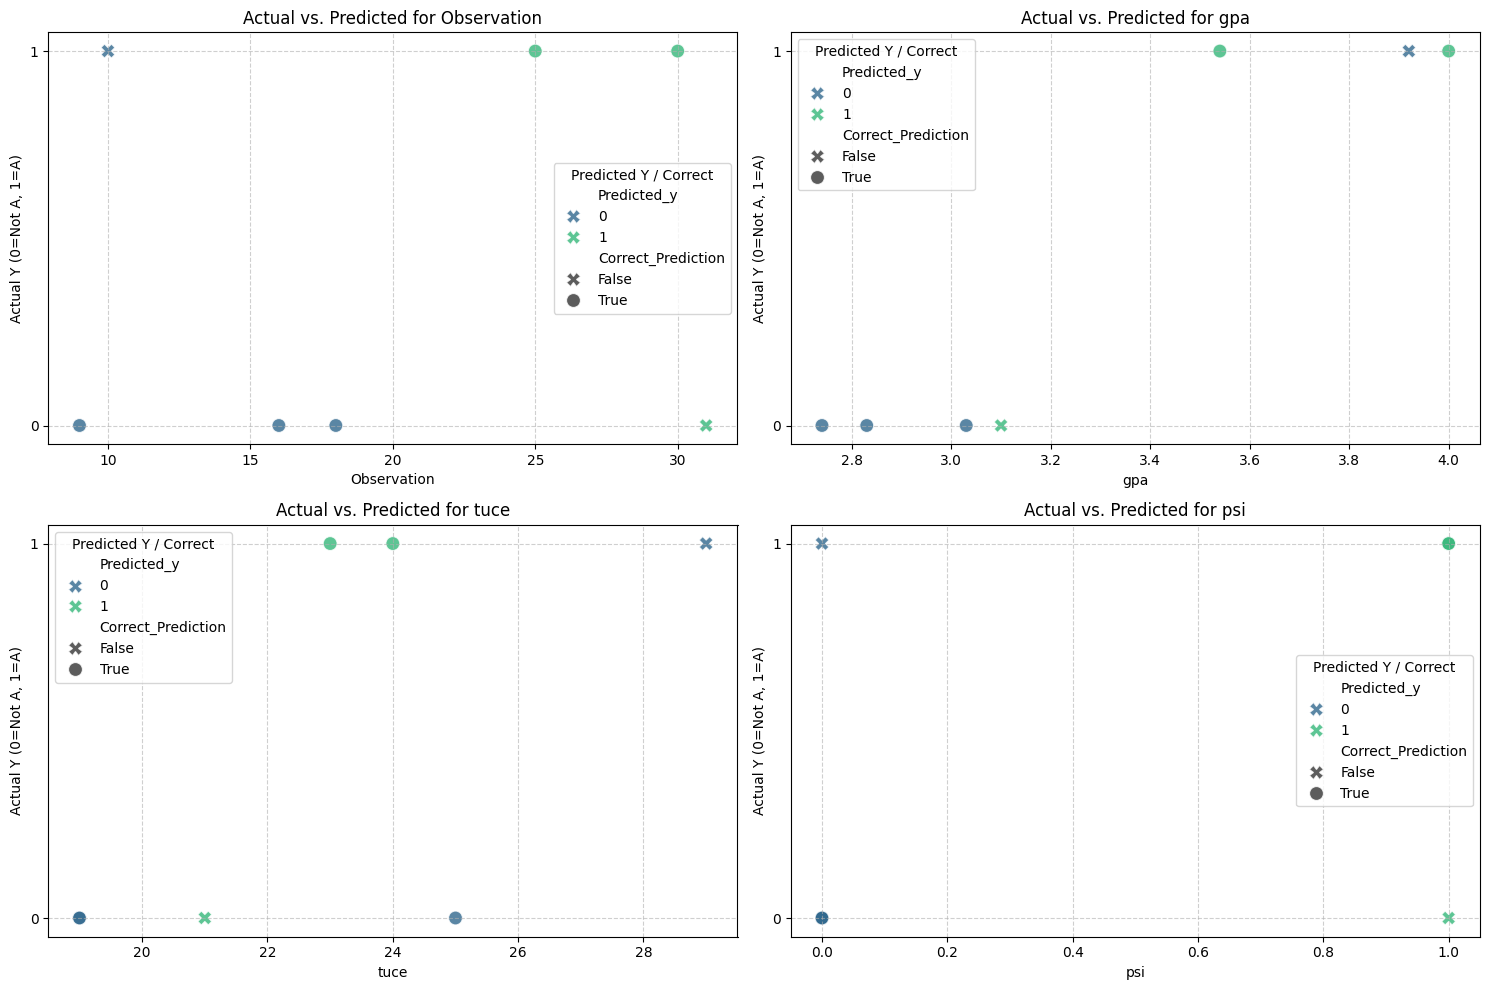

In [71]:
# Re-import necessary libraries if not already in this cell's scope (for robustness in case of re-execution)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for visualization
# Ensure X_test_scaled is available from previous steps; it contains the original feature columns
plot_df = X_test_scaled.copy()
plot_df['Actual_y'] = y_test.values
plot_df['Predicted_y'] = y_pred
plot_df['Correct_Prediction'] = (plot_df['Actual_y'] == plot_df['Predicted_y'])


# Get the feature columns to plot
feature_columns = ['Observation', 'gpa', 'tuce', 'psi']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(feature_columns):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.scatterplot(
        data=plot_df,
        x=feature,
        y='Actual_y',
        hue='Predicted_y', # Color by predicted class
        style='Correct_Prediction', # Use different markers for correct/incorrect predictions
        markers={True: 'o', False: 'X'},
        palette='viridis', # Choose a color palette
        s=100, # Marker size
        alpha=0.8 # Transparency
    )
    plt.title(f'Actual vs. Predicted for {feature}')
    plt.xlabel(feature)
    plt.ylabel('Actual Y (0=Not A, 1=A)')
    plt.yticks([0, 1])
    plt.legend(title='Predicted Y / Correct')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

##Interpretation of Visualizations: Model Predictions vs. Actual Values

The scatter plots above show the actual 'y' values (0 or 1) on the y-axis and each feature on the x-axis for the test set. The points are colored by the model's predicted 'y' value, and the shape indicates whether the prediction was correct (circle) or incorrect (X).

Here's what we can observe from each plot:

-   **Observation:** This feature is likely an identifier and not directly predictive. The plot shows the distribution of actual vs. predicted values across the test samples. We can see the few misclassified points (red 'X's and purple 'X's) are scattered, indicating that these errors are not concentrated around specific observation IDs.

-   **GPA (gpa):**
    -   For students with lower GPAs (e.g., around 2.7-2.8), the model correctly predicts y=0 (not getting an 'A').
    -   For students with higher GPAs (e.g., above 3.5), the model generally predicts y=1 (getting an 'A') correctly.
    -   The misclassifications (X marks) appear where actual y=0 but predicted y=1 (false positives, red X) or where actual y=1 but predicted y=0 (false negatives, purple X). This suggests some overlap or ambiguity in prediction for certain GPA ranges.

-   **TUCE (tuce):**
    -   The model seems to correctly predict y=0 for lower TUCE scores and y=1 for higher TUCE scores.
    -   Similar to GPA, there are misclassifications, indicating that the TUCE score alone isn't a perfect predictor and can lead to errors at certain score thresholds.

-   **PSI (psi):** This is a binary variable (0 or 1).
    -   When psi=0 (no new teaching method), the model largely predicts y=0 (not getting an 'A'). There is one instance where psi=0 but the actual y=1 was incorrectly predicted as y=0 (purple X).
    -   When psi=1 (new teaching method used), the model predominantly predicts y=1 (getting an 'A'). There's one case where psi=1 and actual y=0 was incorrectly predicted as y=1 (red X).
    -   This plot clearly shows how the model uses the PSI factor in its predictions.

In summary, these visualizations provide a granular view of the model's performance on individual data points, helping to identify potential areas where the model struggles (e.g., specific value ranges for GPA or TUCE) or performs well across different features.

# Feature Importance and Visualization

For the Logistic Regression model, the coefficients of the features indicate their importance. A larger absolute value of the coefficient implies a stronger influence on the predicted outcome.

Feature Importances (Coefficients):


,Feature,Coefficient,Absolute_Coefficient
1,gpa,0.785164,0.785164
0,Observation,0.770351,0.770351
3,psi,0.407140,0.407140
2,tuce,0.132778,0.132778


/tmp/ipykernel_9522/3134669461.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Absolute_Coefficient', y='Feature', data=feature_importance_df, palette='viridis')


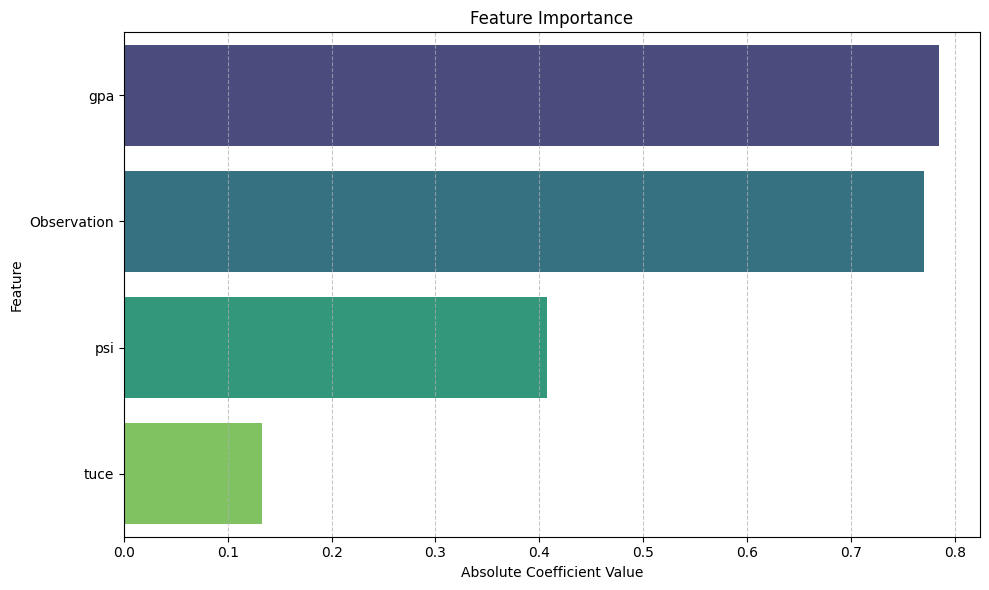

In [73]:

feature_names = X_train_scaled.columns

# coefficients from the trained Logistic Regression model
coefficients = model.coef_[0]


feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Coefficient': np.abs(coefficients)
})

feature_importance_df = feature_importance_df.sort_values(by='Absolute_Coefficient', ascending=False)

print("Feature Importances (Coefficients):")
display(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Absolute_Coefficient', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()